In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the certified dataset
df = pd.read_csv('base_data_v3_soil_corrected.csv')

# Set plot style
sns.set_style("whitegrid")

--- Analyzing Target Variable: 'yield' ---
count    16153.000000
mean         3.738071
std         11.513884
min          0.000000
25%          0.315015
50%          0.666667
75%          1.621884
max        125.956098
Name: yield, dtype: float64


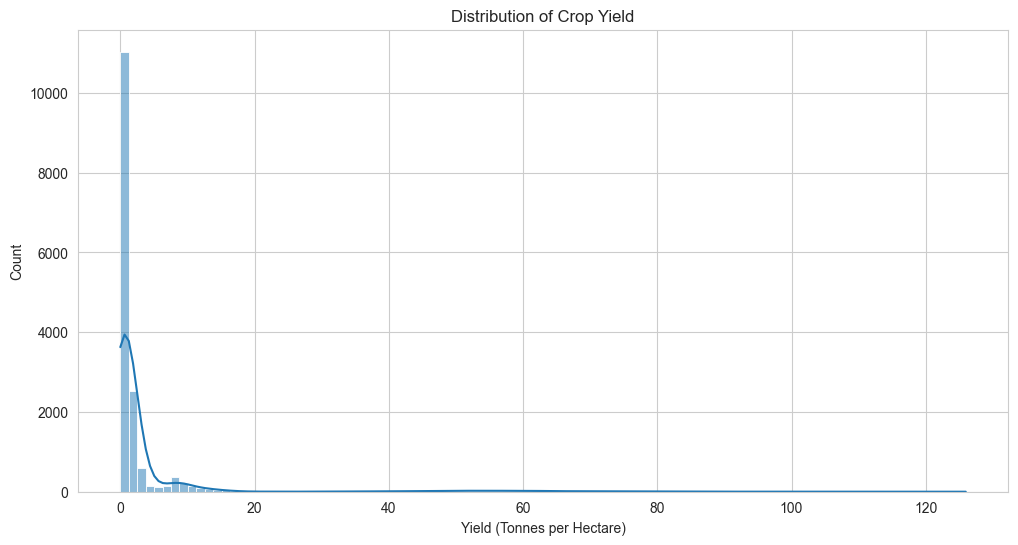

In [3]:
print("--- Analyzing Target Variable: 'yield' ---")
print(df['yield'].describe())

plt.figure(figsize=(12, 6))
sns.histplot(df['yield'], bins=100, kde=True)
plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (Tonnes per Hectare)')
plt.show()


--- Analyzing Numerical Features ---
                area    avg_temp_c  total_precip_mm
count   16153.000000  16153.000000     16153.000000
mean     7716.626014     25.035818       459.874359
std     30303.519836      3.939549       499.076494
min         1.000000     17.146111         0.010000
25%        62.000000     21.913167        70.610000
50%       375.000000     24.344249       300.650000
75%      1885.000000     27.868824       646.140000
max    687000.000000     33.795861      1969.350000


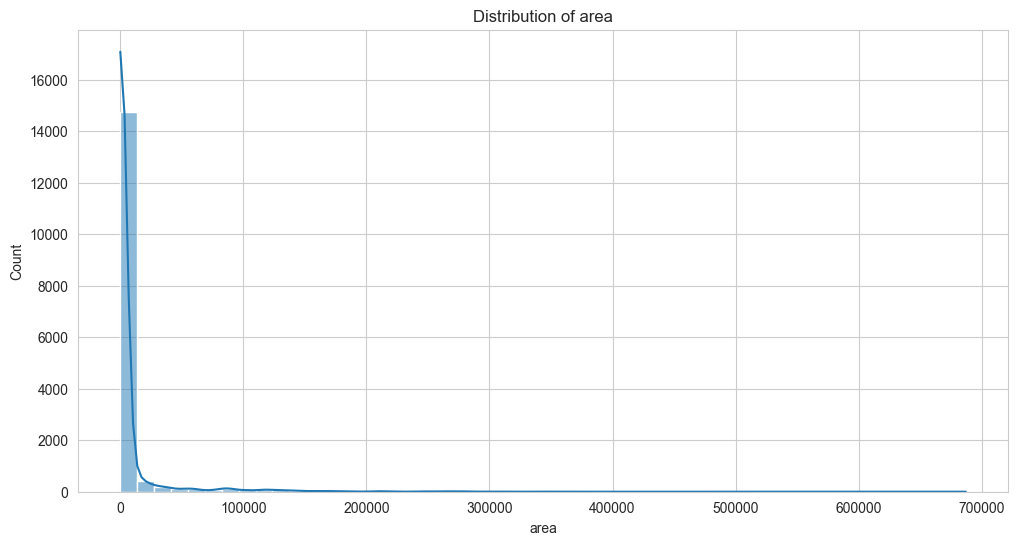

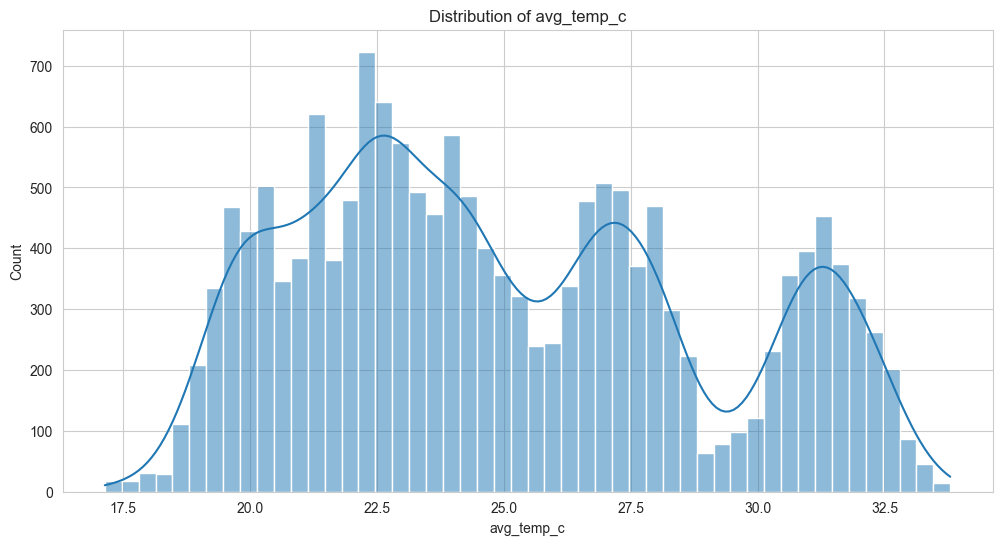

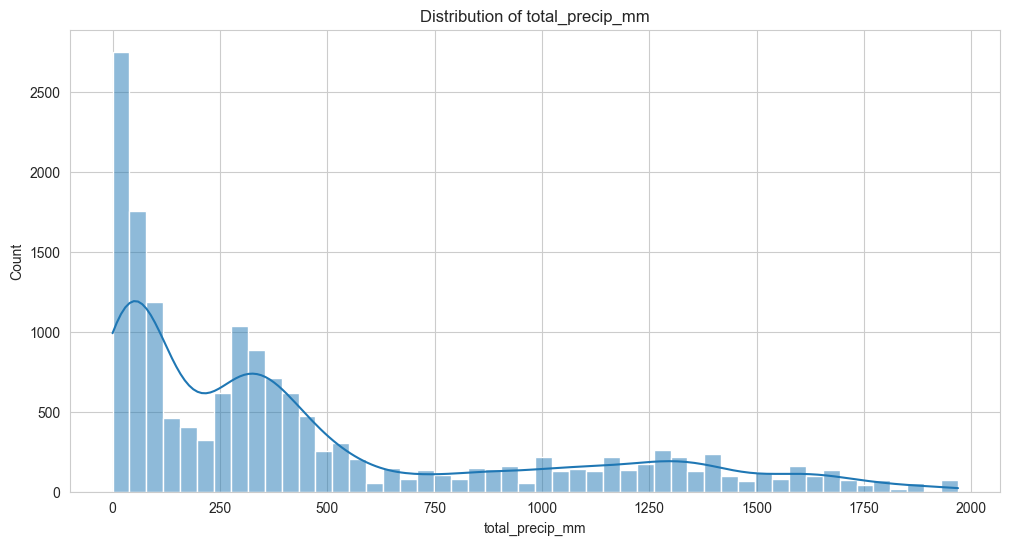

In [4]:
print("\n--- Analyzing Numerical Features ---")
num_features = ['area', 'avg_temp_c', 'total_precip_mm']
print(df[num_features].describe())

for col in num_features:
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

In [5]:
print("\n--- Analyzing Categorical Features ---")
cat_features = ['district', 'crop', 'season', 'primary_soil_type']

for col in cat_features:
    print(f"\n--- Value Counts for {col} (Top 20) ---")
    print(df[col].value_counts().head(20))


--- Analyzing Categorical Features ---

--- Value Counts for district (Top 20) ---
district
sundargarh     630
mayurbhanj     630
rayagada       628
kendujhar      627
ganjam         627
balangir       621
koraput        620
kalahandi      604
anugul         601
nuapada        572
dhenkanal      570
bargarh        563
sambalpur      562
boudh          562
deogarh        559
cuttack        553
nabarangpur    545
gajapati       545
nayagarh       529
kandhamal      516
Name: count, dtype: int64

--- Value Counts for crop (Top 20) ---
crop
Rice                 1684
Urad                 1419
Groundnut            1394
Moong(Green Gram)    1312
Sesamum              1214
Maize                1182
Ragi                  826
Horse-gram            760
Potato                639
Sugarcane             633
Rapeseed &Mustard     632
Wheat                 477
Castor seed           332
Dry chillies          270
Arhar/Tur             252
Sweet potato          243
Sunflower             232
Onion         


--- Correlation Analysis ---


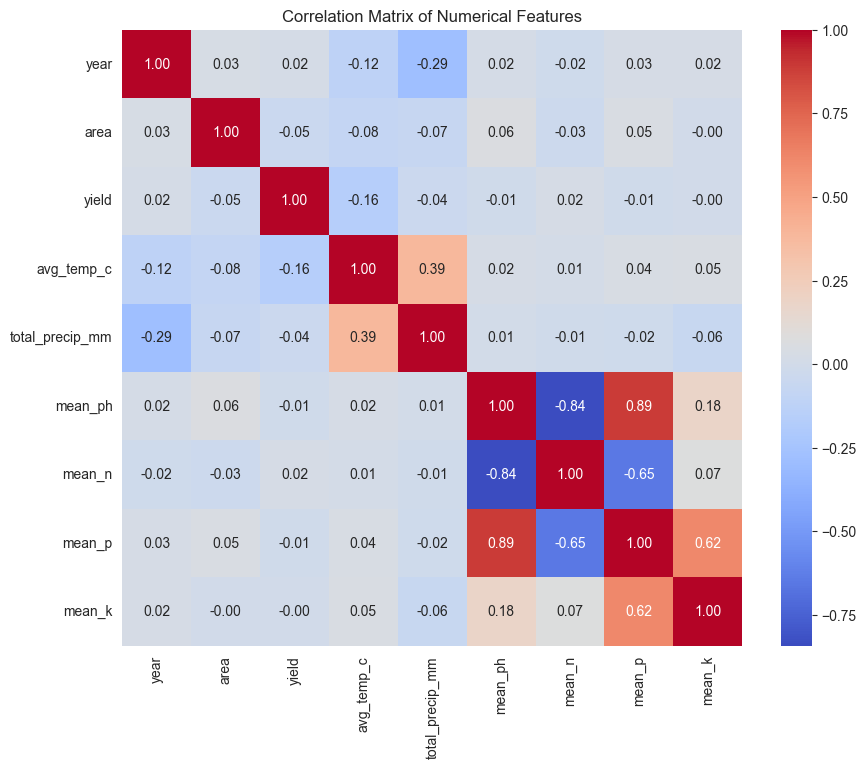


Correlations with 'yield':
yield              1.000000
mean_n             0.021549
year               0.021261
mean_k            -0.000540
mean_ph           -0.009367
mean_p            -0.009448
total_precip_mm   -0.037025
area              -0.048239
avg_temp_c        -0.160966
Name: yield, dtype: float64


In [7]:
import numpy as np
print("\n--- Correlation Analysis ---")
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("\nCorrelations with 'yield':")
print(corr_matrix['yield'].sort_values(ascending=False))